# Image Enhancement for Annotated YOLO Dataset
## Safe preprocessing before YOLOv8 training

This notebook reads images from your **annotated_frames** folder,  
applies safe enhancements (CLAHE, denoising, sharpening, gamma correction),  
and saves the enhanced images into a new folder **enhanced_annotated_frames**  
together with the **original label files copied unchanged**.

->Label `.txt` files are **never modified** — only image appearance changes.  
->Image dimensions stay the same — boxes still point to the correct locations.  
->You then point your YOLO training to the new **enhanced_annotated_frames** folder.

---
## Cell 1 — Install dependencies (run once)

In [1]:
# Run this cell first if you do not have these libraries installed
!pip install opencv-python-headless numpy matplotlib tqdm --quiet

---
## Cell 2 — Imports

In [2]:
import cv2
import numpy as np
import shutil
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

print("✅ Imports successful.")

✅ Imports successful.


---
## Cell 3 — Configure your folder paths

 **Change these two paths to match your computer.**

In [3]:
# ── CHANGE THESE TO MATCH YOUR COMPUTER ──────────────────────────────────────

# Folder that contains your annotated images (.jpg/.png) AND label files (.txt)
ANNOTATED_DIR = Path(r"C:\Users\KAREEM ZZIWA\Documents\COMPUTER VISION\annotated_frames")

# Folder where enhanced images + copied labels will be saved (will be created automatically)
ENHANCED_DIR  = Path(r"C:\Users\KAREEM ZZIWA\Documents\COMPUTER VISION\enhanced_annotated_frames")

# ─────────────────────────────────────────────────────────────────────────────

ENHANCED_DIR.mkdir(parents=True, exist_ok=True)

# Count what is inside the annotated folder
images = sorted(list(ANNOTATED_DIR.glob("*.jpg")) + list(ANNOTATED_DIR.glob("*.png")))
labels = sorted(ANNOTATED_DIR.glob("*.txt"))

print(f"📁 Annotated folder  : {ANNOTATED_DIR}")
print(f"📁 Enhanced folder   : {ENHANCED_DIR}")
print(f"🖼️  Images found      : {len(images)}")
print(f"🏷️  Label files found : {len(labels)}")

if len(images) == 0:
    print("\n⚠️  WARNING: No images found! Please check your ANNOTATED_DIR path above.")

📁 Annotated folder  : C:\Users\KAREEM ZZIWA\Documents\COMPUTER VISION\annotated_frames
📁 Enhanced folder   : C:\Users\KAREEM ZZIWA\Documents\COMPUTER VISION\enhanced_annotated_frames
🖼️  Images found      : 527
🏷️  Label files found : 527


---
## Cell 4 — Define the enhancement functions

Each function takes an image, improves it, and returns it.  
None of them change the image size or move anything inside the image.

In [4]:
def apply_clahe(img_bgr):
    """
    CLAHE — Contrast Limited Adaptive Histogram Equalisation.
    Improves contrast in dark or unevenly lit images.
    Works on the brightness channel only, so colours stay natural.
    """
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)   # split into brightness + colour
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)                             # improve brightness channel
    lab_eq = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)


def apply_denoise(img_bgr):
    """
    Gaussian Blur — reduces graininess and random noise in the image.
    Makes the image slightly softer but cleaner.
    """
    return cv2.GaussianBlur(img_bgr, (3, 3), 0)   # (3,3) is gentler than (5,5)


def apply_sharpen(img_bgr):
    """
    Sharpening — makes edges and fine details (like leaf veins) crisper.
    """
    kernel = np.array([[0, -1,  0],
                       [-1,  5, -1],
                       [0, -1,  0]])
    return cv2.filter2D(img_bgr, -1, kernel)


def apply_gamma(img_bgr, gamma=1.2):
    """
    Gamma correction — brightens slightly dark images.
    gamma > 1.0 = brighter,  gamma < 1.0 = darker.
    Default 1.2 gives a gentle lift without over-exposing.
    """
    table = np.array([(i / 255.0) ** (1.0 / gamma) * 255
                      for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img_bgr, table)


def enhance_image(img_bgr):
    """
    Master function — applies all enhancements in sequence.
    Order: CLAHE → denoise → sharpen → gamma correction.
    """
    img = apply_clahe(img_bgr)      # step 1: fix contrast
    img = apply_denoise(img)        # step 2: remove noise
    img = apply_sharpen(img)        # step 3: sharpen edges
    img = apply_gamma(img, 1.2)     # step 4: brighten gently
    return img


print("✅ Enhancement functions defined.")

✅ Enhancement functions defined.


---
## Cell 5 — Preview: see what enhancement looks like on one image

This cell shows a side-by-side comparison of one image before and after each enhancement step.  
**No files are saved or changed yet** — this is just a preview.

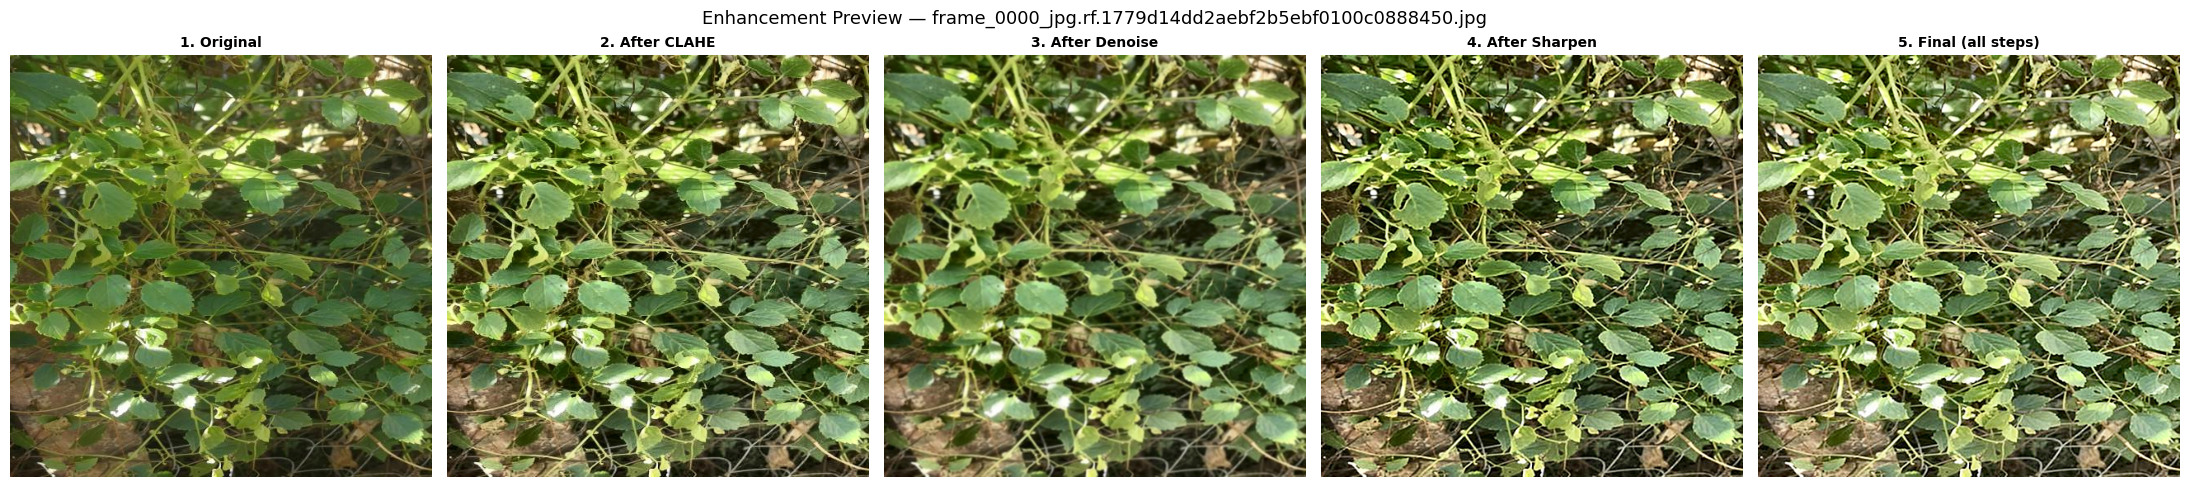


Image size before: 512x512 px
Image size after : 512x512 px
✅ Size is UNCHANGED — label files will remain valid.


In [5]:
if len(images) == 0:
    print("⚠️  No images found. Check your ANNOTATED_DIR path in Cell 3.")
else:
    # Pick the first image for preview
    preview_path = images[0]
    original = cv2.imread(str(preview_path))

    steps = [
        ("1. Original",          original),
        ("2. After CLAHE",       apply_clahe(original)),
        ("3. After Denoise",     apply_denoise(apply_clahe(original))),
        ("4. After Sharpen",     apply_sharpen(apply_denoise(apply_clahe(original)))),
        ("5. Final (all steps)", enhance_image(original)),
    ]

    fig, axes = plt.subplots(1, len(steps), figsize=(22, 5))
    for ax, (title, img) in zip(axes, steps):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.axis('off')

    plt.suptitle(f"Enhancement Preview — {preview_path.name}", fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f"\nImage size before: {original.shape[1]}x{original.shape[0]} px")
    print(f"Image size after : {enhance_image(original).shape[1]}x{enhance_image(original).shape[0]} px")
    print("✅ Size is UNCHANGED — label files will remain valid.")

---
## Cell 6 — Apply enhancement to ALL images and copy labels

This is the main processing step.  
- Every image is enhanced and saved to `enhanced_annotated_frames`  
- Every matching `.txt` label file is copied across **unchanged**  
- If an image has no label file, the image is still enhanced (a warning is shown)

In [6]:
no_label_count   = 0
failed_count     = 0
processed_count  = 0

print(f"Starting enhancement of {len(images)} images...\n")

for img_path in tqdm(images, desc="Enhancing images"):

    # ── Read the image ──────────────────────────────────────────────────────
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"  ⚠️  Could not read: {img_path.name} — skipping.")
        failed_count += 1
        continue

    # ── Enhance it ──────────────────────────────────────────────────────────
    enhanced = enhance_image(img)

    # ── Save enhanced image to the new folder (same filename) ───────────────
    out_img_path = ENHANCED_DIR / img_path.name
    cv2.imwrite(str(out_img_path), enhanced)

    # ── Copy the label file unchanged ───────────────────────────────────────
    label_path = ANNOTATED_DIR / (img_path.stem + ".txt")
    if label_path.exists():
        shutil.copy(str(label_path), str(ENHANCED_DIR / label_path.name))
    else:
        no_label_count += 1

    processed_count += 1

# ── Summary ─────────────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  ✅ Images enhanced and saved : {processed_count}")
print(f"  🏷️  Label files copied        : {processed_count - no_label_count}")
print(f"  ⚠️  Images with no label file : {no_label_count}")
print(f"  ❌ Failed (unreadable files)  : {failed_count}")
print(f"{'='*50}")
print(f"\n📁 Enhanced dataset saved to:\n   {ENHANCED_DIR}")

Starting enhancement of 527 images...



Enhancing images: 100%|██████████| 527/527 [00:10<00:00, 48.97it/s]


  ✅ Images enhanced and saved : 527
  🏷️  Label files copied        : 527
  ⚠️  Images with no label file : 0
  ❌ Failed (unreadable files)  : 0

📁 Enhanced dataset saved to:
   C:\Users\KAREEM ZZIWA\Documents\COMPUTER VISION\enhanced_annotated_frames


---
## Cell 7 — Verify: check the enhanced folder contents

In [7]:
enhanced_images = sorted(list(ENHANCED_DIR.glob("*.jpg")) + list(ENHANCED_DIR.glob("*.png")))
enhanced_labels = sorted(ENHANCED_DIR.glob("*.txt"))

print(f"Enhanced folder contents:")
print(f"  🖼️  Images : {len(enhanced_images)}")
print(f"  🏷️  Labels : {len(enhanced_labels)}")

# Spot-check: confirm a random enhanced image has the same size as the original
if enhanced_images:
    sample_enh  = cv2.imread(str(enhanced_images[0]))
    sample_orig = cv2.imread(str(ANNOTATED_DIR / enhanced_images[0].name))

    print(f"\nSpot-check on '{enhanced_images[0].name}':")
    print(f"  Original size  : {sample_orig.shape[1]} x {sample_orig.shape[0]} px")
    print(f"  Enhanced size  : {sample_enh.shape[1]} x {sample_enh.shape[0]} px")

    if sample_orig.shape == sample_enh.shape:
        print("  ✅ Sizes match — labels are still valid!")
    else:
        print("  ❌ Sizes differ — something went wrong!")

Enhanced folder contents:
  🖼️  Images : 527
  🏷️  Labels : 527

Spot-check on 'frame_0000_jpg.rf.1779d14dd2aebf2b5ebf0100c0888450.jpg':
  Original size  : 512 x 512 px
  Enhanced size  : 512 x 512 px
  ✅ Sizes match — labels are still valid!


---
## Cell 8 — Visual check: compare 6 original vs enhanced images side by side

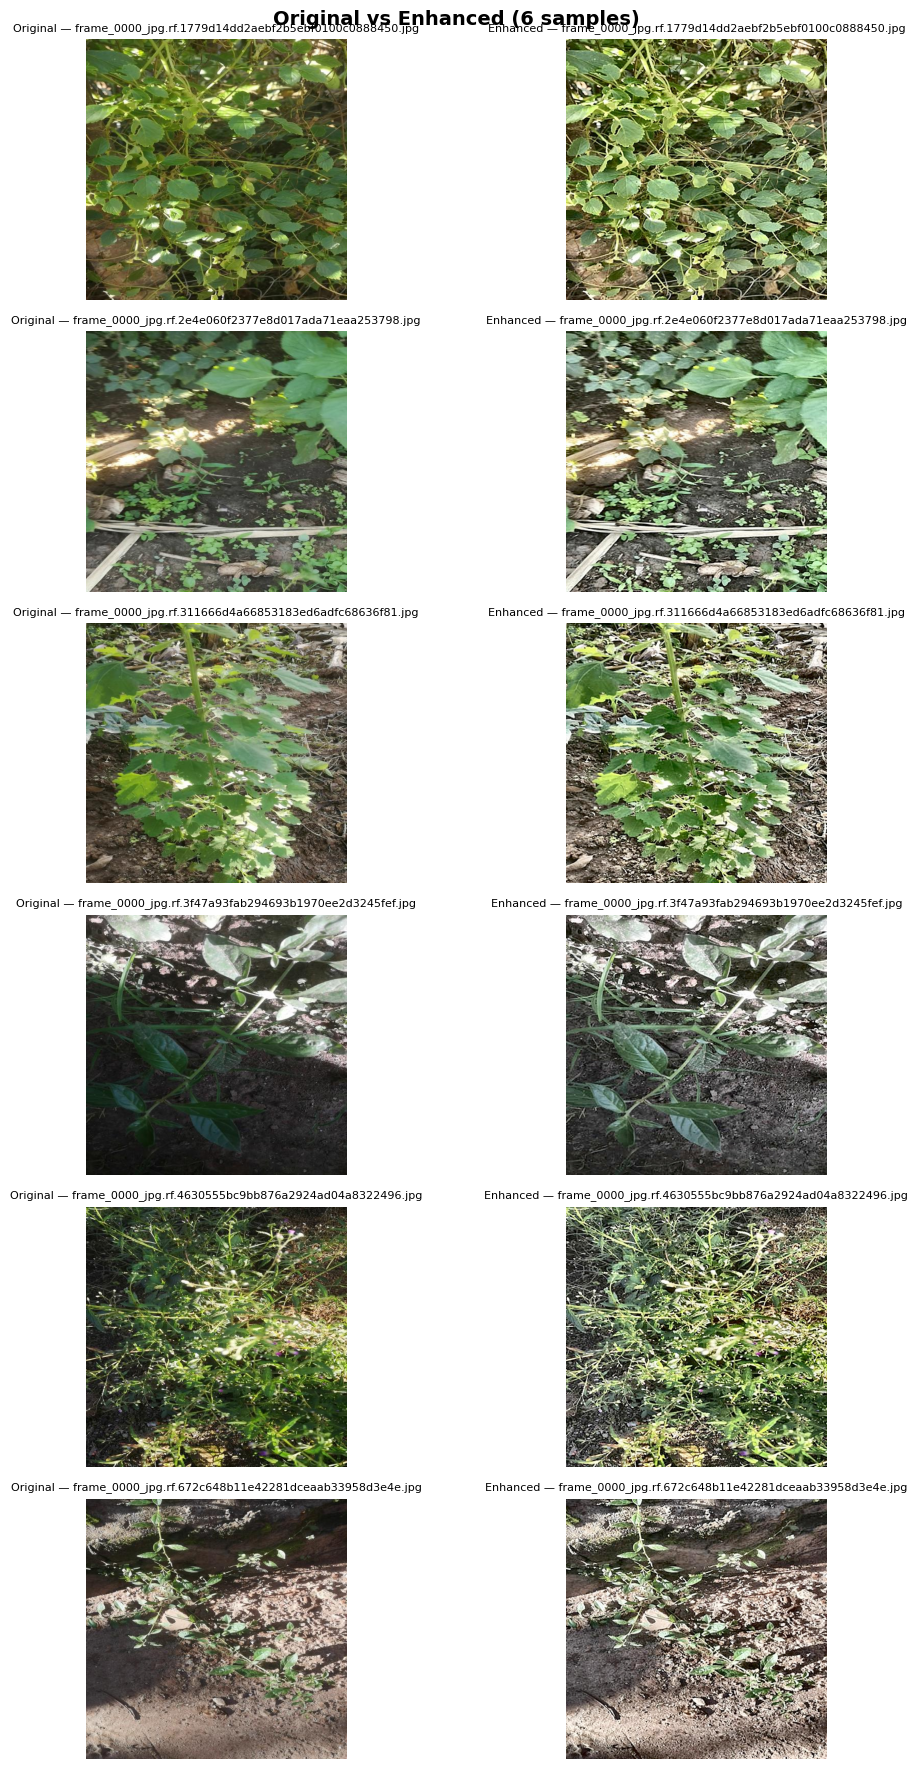

In [8]:
sample_count = min(6, len(enhanced_images))

fig, axes = plt.subplots(sample_count, 2, figsize=(12, sample_count * 3))
if sample_count == 1:
    axes = [axes]

for i in range(sample_count):
    enh_path  = enhanced_images[i]
    orig_path = ANNOTATED_DIR / enh_path.name

    orig = cv2.cvtColor(cv2.imread(str(orig_path)), cv2.COLOR_BGR2RGB)
    enh  = cv2.cvtColor(cv2.imread(str(enh_path)),  cv2.COLOR_BGR2RGB)

    axes[i][0].imshow(orig)
    axes[i][0].set_title(f"Original — {enh_path.name}", fontsize=8)
    axes[i][0].axis('off')

    axes[i][1].imshow(enh)
    axes[i][1].set_title(f"Enhanced — {enh_path.name}", fontsize=8)
    axes[i][1].axis('off')

plt.suptitle("Original vs Enhanced (6 samples)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Cell 9 — What to do next: update your training path

Now that enhancement is done, go back to your **main project notebook** and make **one small change**:  

In **Section 6 (Task 5 — Build Object Detection Model)**, find the line that sets `ANNOTATED_DIR`:  

```python
# BEFORE (original images)
ANNOTATED_DIR = Path(r"C:\Users\KAREEM ZZIWA\Documents\COMPUTER VISION\annotated_frames")
```

Change it to point to the enhanced folder:

```python
# AFTER (enhanced images)
ANNOTATED_DIR = Path(r"C:\Users\KAREEM ZZIWA\Documents\COMPUTER VISION\enhanced_annotated_frames")
```

Then re-run Section 6 onwards. Your YOLO model will now train on the enhanced images. ✅